# Experiment 4: Time vs Objective

Compare PALM, iPALM, and FISTA-PALM using wall-clock time rather than iteration count.

**Setup**
- Matrix sizes: $100 \times 80$, $500 \times 200$, and $1000 \times 600$
- Ranks: $r = 10$, $r = 50$, and $r = 200$
- Sparsity levels in $Y$: $10\%$, $25\%$, and $33\%$
- Initialisation: random nonnegative
- Iterations: $100$

**Goal**

Evaluate whether faster convergence by iteration also corresponds to faster convergence in runtime.

In [5]:
import sys
from pathlib import Path

import time

import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT))

from src.solvers.palm import PALM
from src.solvers.ipalm import IPALM
from src.solvers.fista_palm import FISTAPALM

from src.utils.data import generate_low_rank_matrix_problem
from src.utils.problem_factory import make_matrix_factorisation_problem
from src.utils.plotting import plot_time_grid
from src.utils.io import make_fig_path, save_table

In [6]:
np.random.seed(42)

matrix_configs = [
    (100, 80, 10),
    (500, 200, 50),
    (1000, 600, 200),
]

sparsity_levels = [0.10, 0.25, 0.33]
max_iter = 100
gamma = 1.2

solvers = {
    "PALM": PALM(max_iter=max_iter),
    "iPALM": IPALM(max_iter=max_iter),
    "FISTA-PALM": FISTAPALM(max_iter=max_iter),
}

## Run timed experiments

For each matrix size and sparsity level, record the objective history and elapsed time per iteration.

In [7]:
results = []
records = []

for sparsity in sparsity_levels:
    for m, n, r in matrix_configs:
        label = f"{m}x{n}, r={r}, s={int(sparsity * 100)}%"

        A, X0, Y0, _, _ = generate_low_rank_matrix_problem(
            m, n, r, sparsity=sparsity, seed=42
        )

        problem = make_matrix_factorisation_problem(
            A, r, sparsity, gamma=gamma
        )

        method_data = {}

        for method_name, solver in solvers.items():
            start = time.perf_counter()
            _, _, hist = solver.solve(problem, X0.copy(), Y0.copy())
            runtime = time.perf_counter() - start

            times = np.linspace(0, runtime, len(hist))

            method_data[method_name] = (times, hist)

            records.append({
                "Matrix": f"{m}x{n}",
                "m": m,
                "n": n,
                "rank": r,
                "Sparsity": f"{int(sparsity * 100)}%",
                "Method": method_name,
                "Final Objective": hist[-1],
                "Iterations": len(hist) - 1,
                "Runtime (s)": runtime,
            })

        results.append((label, method_data))

## Time vs objective curves

Objective value plotted against elapsed wall-clock time.

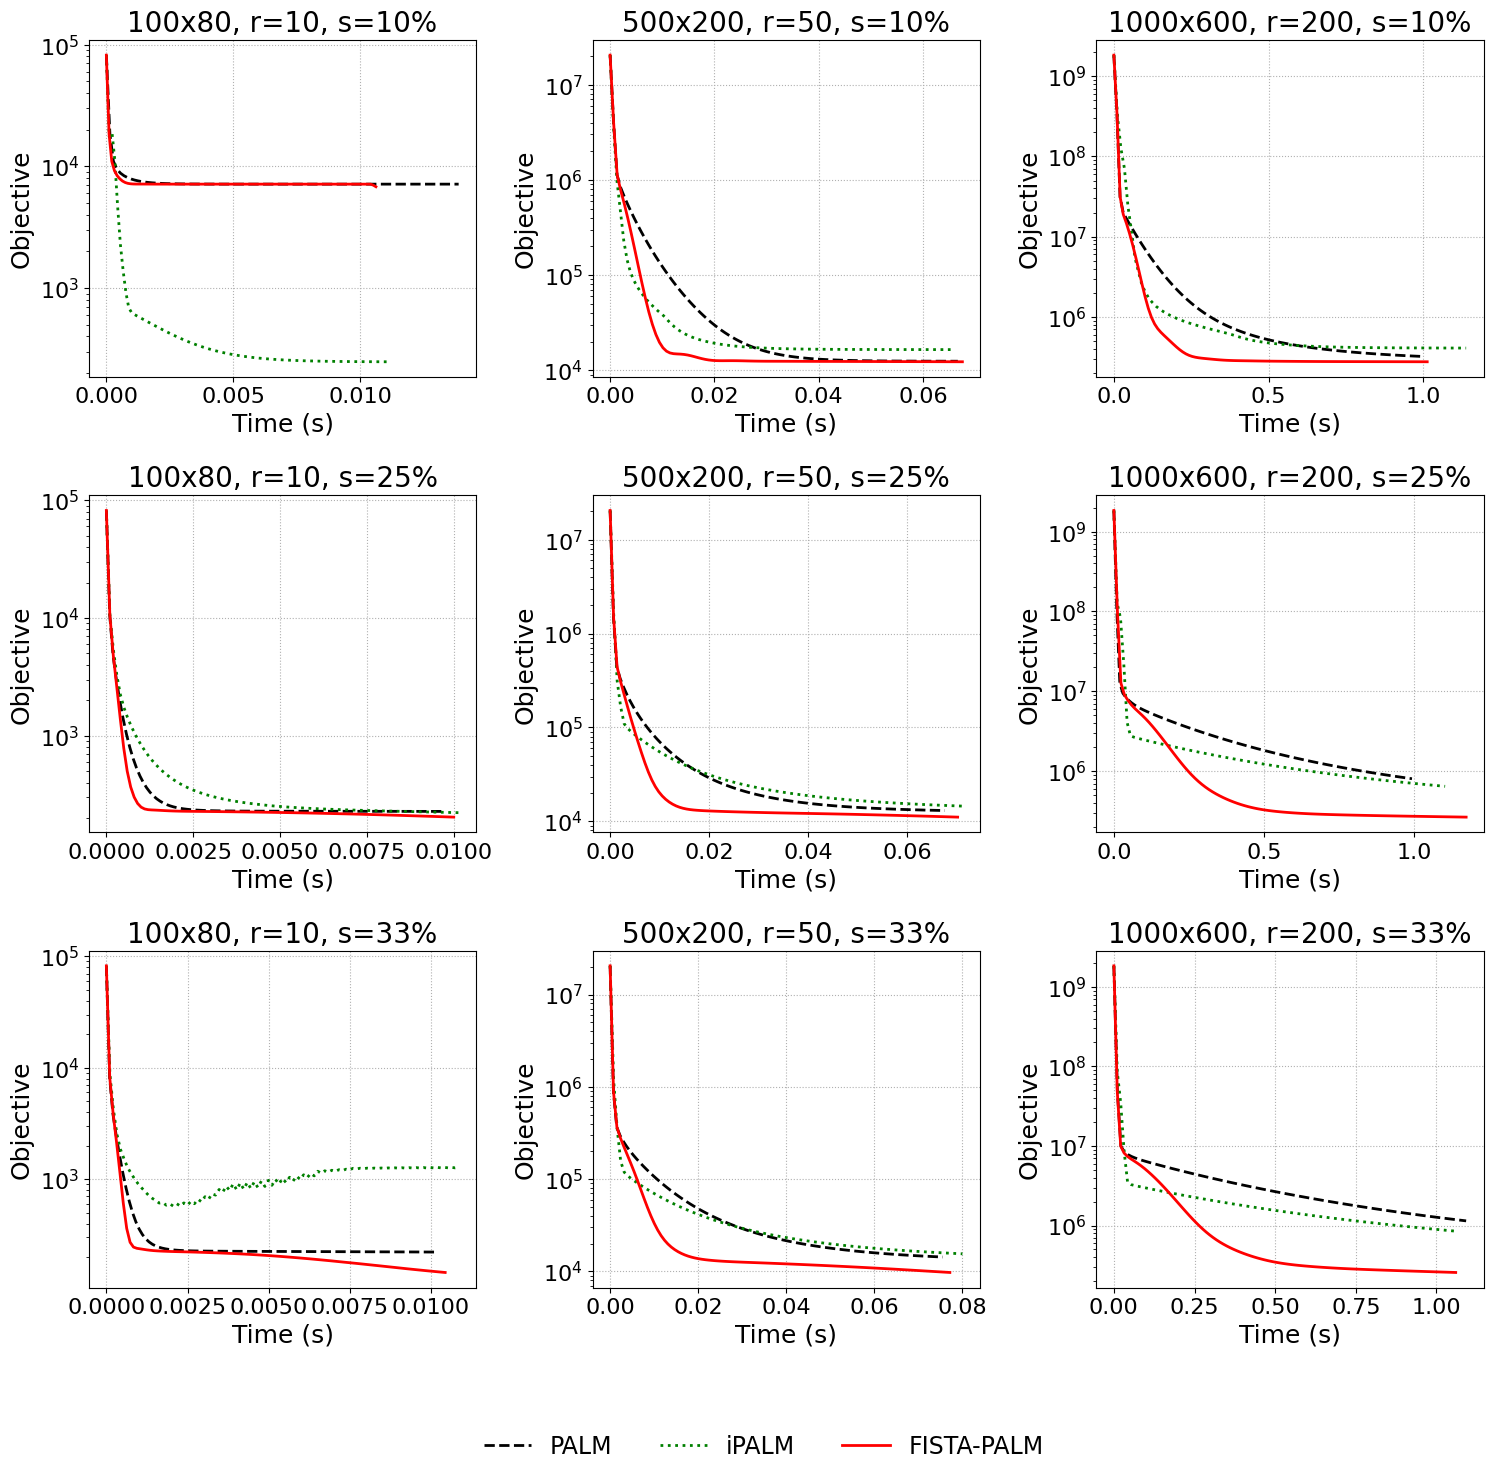

In [8]:
params = {
    "configs": len(matrix_configs),
    "slevels": len(sparsity_levels),
    "iter": max_iter,
}

plot_time_grid(
    results,
    save_path=make_fig_path(ROOT, "time_vs_objective", params),
)

## Runtime summary table

Final objective values, iteration counts, and runtime for each method.

In [9]:
df = pd.DataFrame(records)

save_table(
    df,
    ROOT,
    "time_vs_objective_summary",
    params,
)

df

,Matrix,m,n,rank,Sparsity,Method,Final Objective,Iterations,Runtime (s)
0,100x80,100,80,10,10%,PALM,7.135109e+03,100,0.013877
1,100x80,100,80,10,10%,iPALM,2.472914e+02,100,0.011043
2,100x80,100,80,10,10%,FISTA-PALM,6.792020e+03,100,0.010619
3,500x200,500,200,50,10%,PALM,1.247284e+04,100,0.066669
4,500x200,500,200,50,10%,iPALM,1.652135e+04,100,0.065285
5,500x200,500,200,50,10%,FISTA-PALM,1.230661e+04,100,0.067544
6,1000x600,1000,600,200,10%,PALM,3.204404e+05,100,0.999291
7,1000x600,1000,600,200,10%,iPALM,4.079542e+05,100,1.138480
8,1000x600,1000,600,200,10%,FISTA-PALM,2.752331e+05,100,1.012683
9,100x80,100,80,10,25%,PALM,2.274849e+02,100,0.009661


## Observations

- Runtime increases sharply with matrix size, especially for the $1000 \times 600$ case.
- FISTA-PALM usually reaches the lowest objective for the medium and large matrix sizes within a similar runtime budget.
- For the smallest matrix, runtime differences are negligible, so objective behaviour is more informative than wall-clock time.
- iPALM is not consistently faster in objective reduction despite having comparable runtimes to the other methods.
- The time-based plots confirm that FISTA-PALM’s advantage is not only iteration-based; it also gives stronger objective reduction over time in most larger configurations.

**Note.** The time axis uses total solver runtime distributed across iterations, so it gives an approximate wall-clock comparison rather than exact per-iteration timings.